In [19]:
import sys
!{sys.executable} -m pip install xgboost catboost lightgbm imbalanced-learn openpyxl

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier

In [21]:
# Load dataset
df = pd.read_excel("data_no_enrolled.xlsx")

# Clean target
df["Target"] = df["Target"].astype(str).str.strip().str.lower()
df["Target"] = df["Target"].map({"graduate": 0, "dropout": 1})

# Clean column names for model compatibility
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
)

print(df.head())
print("\nTarget distribution:")
print(df["Target"].value_counts(dropna=False))
print("\nNaN count in Target:", df["Target"].isna().sum())

   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous_qualification_grade_  Nacionality  Mother_s_qualification  \
0                          122.0            1                      19   
1                          160.0            1                       1   
2                          122.0         

In [22]:
print("Dataset shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\nData types:")
print(df.dtypes)

Dataset shape: (3630, 37)

Missing values per column:
Marital_status                                   0
Age_at_enrollment                                0
Curricular_units_1st_sem_credited_               0
Curricular_units_1st_sem_enrolled_               0
Curricular_units_1st_sem_evaluations_            0
Curricular_units_1st_sem_approved_               0
Curricular_units_1st_sem_grade_                  0
Curricular_units_1st_sem_without_evaluations_    0
Curricular_units_2nd_sem_credited_               0
Curricular_units_2nd_sem_enrolled_               0
Curricular_units_2nd_sem_evaluations_            0
Curricular_units_2nd_sem_approved_               0
Curricular_units_2nd_sem_grade_                  0
Curricular_units_2nd_sem_without_evaluations_    0
Unemployment_rate                                0
Inflation_rate                                   0
GDP                                              0
International                                    0
Scholarship_holder          

In [23]:
# Early warning model: remove 2nd semester columns
second_sem_cols = [col for col in df.columns if "2nd_sem" in col.lower()]

early_df = df.drop(columns=second_sem_cols)
full_df = df.copy()

X_early = early_df.drop("Target", axis=1)
y_early = early_df["Target"]

X_full = full_df.drop("Target", axis=1)
y_full = full_df["Target"]

print("Number of 2nd sem columns removed from early model:", len(second_sem_cols))
print("Early model shape:", X_early.shape)
print("Full model shape:", X_full.shape)
print("Any 2nd sem columns in early model?:", any("2nd_sem" in col.lower() for col in X_early.columns))

Number of 2nd sem columns removed from early model: 6
Early model shape: (3630, 30)
Full model shape: (3630, 36)
Any 2nd sem columns in early model?: False


In [25]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [26]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_early, y_early,
    test_size=0.2,
    random_state=42,
    stratify=y_early
)

smote_e = SMOTE(random_state=42)
X_train_smote_e, y_train_smote_e = smote_e.fit_resample(X_train_e, y_train_e)

print("Before SMOTE (Early):")
print(y_train_e.value_counts())

print("\nAfter SMOTE (Early):")
print(y_train_smote_e.value_counts())

Before SMOTE (Early):
Target
0    1767
1    1137
Name: count, dtype: int64

After SMOTE (Early):
Target
1    1767
0    1767
Name: count, dtype: int64


In [27]:
# Early models
xgb_model_e = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

cat_model_e = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

lgb_model_e = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

hgb_model_e = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

ada_model_e = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

# Train early models
xgb_model_e.fit(X_train_smote_e, y_train_smote_e)
cat_model_e.fit(X_train_smote_e, y_train_smote_e)
lgb_model_e.fit(X_train_smote_e, y_train_smote_e)
hgb_model_e.fit(X_train_smote_e, y_train_smote_e)
ada_model_e.fit(X_train_smote_e, y_train_smote_e)

print("All early models trained successfully.")

[LightGBM] [Info] Number of positive: 1767, number of negative: 1767
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1940
[LightGBM] [Info] Number of data points in the train set: 3534, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [28]:
y_pred_xgb_e = xgb_model_e.predict(X_test_e)
y_pred_cat_e = cat_model_e.predict(X_test_e)
y_pred_lgb_e = lgb_model_e.predict(X_test_e)
y_pred_hgb_e = hgb_model_e.predict(X_test_e)
y_pred_ada_e = ada_model_e.predict(X_test_e)

In [29]:
comparison_early = pd.DataFrame([
    evaluate_model("Early XGBoost", y_test_e, y_pred_xgb_e),
    evaluate_model("Early CatBoost", y_test_e, y_pred_cat_e),
    evaluate_model("Early LightGBM", y_test_e, y_pred_lgb_e),
    evaluate_model("Early HistGradientBoosting", y_test_e, y_pred_hgb_e),
    evaluate_model("Early AdaBoost", y_test_e, y_pred_ada_e),
])

comparison_early

,Model,Accuracy,Precision,Recall,F1 Score
0,Early XGBoost,0.907713,0.878049,0.887324,0.882662
1,Early CatBoost,0.903581,0.876761,0.876761,0.876761
2,Early LightGBM,0.911846,0.884615,0.890845,0.887719
3,Early HistGradientBoosting,0.902204,0.868512,0.883803,0.876091
4,Early AdaBoost,0.867769,0.815436,0.855634,0.835052


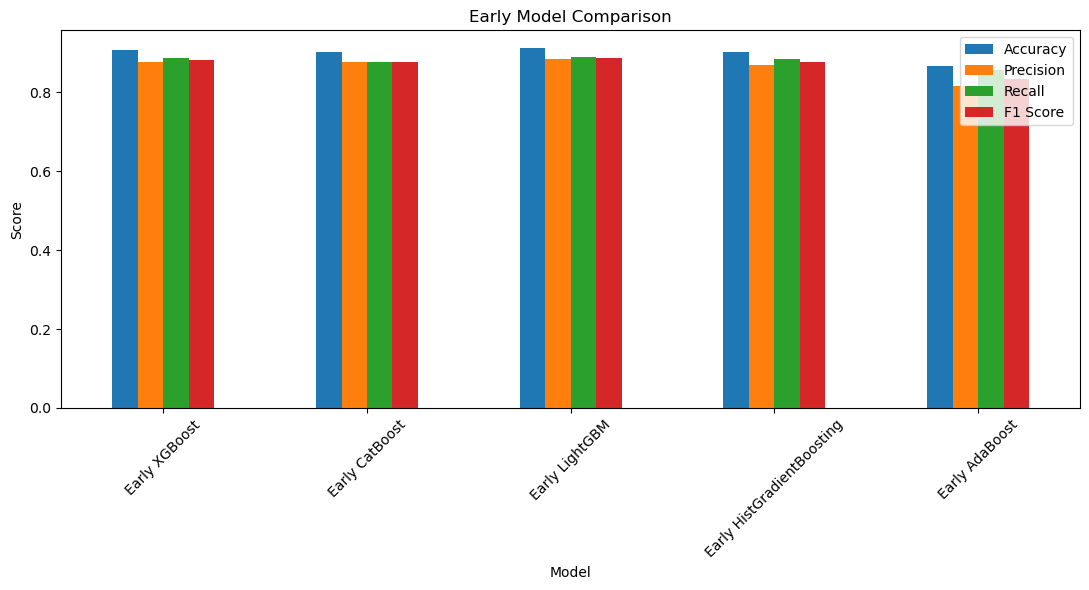

In [30]:
comparison_early.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(11, 6)
)
plt.title("Early Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
early_models_preds = {
    "Early XGBoost": y_pred_xgb_e,
    "Early CatBoost": y_pred_cat_e,
    "Early LightGBM": y_pred_lgb_e,
    "Early HistGradientBoosting": y_pred_hgb_e,
    "Early AdaBoost": y_pred_ada_e
}

for model_name, preds in early_models_preds.items():
    print(f"\n{'='*50}")
    print(model_name)
    print(classification_report(y_test_e, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_e, preds))


Early XGBoost
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       442
           1       0.88      0.89      0.88       284

    accuracy                           0.91       726
   macro avg       0.90      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726

Confusion Matrix:
[[407  35]
 [ 32 252]]

Early CatBoost
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       442
           1       0.88      0.88      0.88       284

    accuracy                           0.90       726
   macro avg       0.90      0.90      0.90       726
weighted avg       0.90      0.90      0.90       726

Confusion Matrix:
[[407  35]
 [ 35 249]]

Early LightGBM
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       442
           1       0.88      0.89      0.89       284

    accuracy                           0.91       726

In [32]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

smote_f = SMOTE(random_state=42)
X_train_smote_f, y_train_smote_f = smote_f.fit_resample(X_train_f, y_train_f)

print("Before SMOTE (Full):")
print(y_train_f.value_counts())

print("\nAfter SMOTE (Full):")
print(y_train_smote_f.value_counts())

Before SMOTE (Full):
Target
0    1767
1    1137
Name: count, dtype: int64

After SMOTE (Full):
Target
1    1767
0    1767
Name: count, dtype: int64


In [33]:
# Full models
xgb_model_f = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

cat_model_f = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

lgb_model_f = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

hgb_model_f = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

ada_model_f = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

# Train full models
xgb_model_f.fit(X_train_smote_f, y_train_smote_f)
cat_model_f.fit(X_train_smote_f, y_train_smote_f)
lgb_model_f.fit(X_train_smote_f, y_train_smote_f)
hgb_model_f.fit(X_train_smote_f, y_train_smote_f)
ada_model_f.fit(X_train_smote_f, y_train_smote_f)

print("All full models trained successfully.")

[LightGBM] [Info] Number of positive: 1767, number of negative: 1767
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2288
[LightGBM] [Info] Number of data points in the train set: 3534, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [34]:
y_pred_xgb_f = xgb_model_f.predict(X_test_f)
y_pred_cat_f = cat_model_f.predict(X_test_f)
y_pred_lgb_f = lgb_model_f.predict(X_test_f)
y_pred_hgb_f = hgb_model_f.predict(X_test_f)
y_pred_ada_f = ada_model_f.predict(X_test_f)

In [35]:
comparison_full = pd.DataFrame([
    evaluate_model("Full XGBoost", y_test_f, y_pred_xgb_f),
    evaluate_model("Full CatBoost", y_test_f, y_pred_cat_f),
    evaluate_model("Full LightGBM", y_test_f, y_pred_lgb_f),
    evaluate_model("Full HistGradientBoosting", y_test_f, y_pred_hgb_f),
    evaluate_model("Full AdaBoost", y_test_f, y_pred_ada_f),
])

comparison_full

,Model,Accuracy,Precision,Recall,F1 Score
0,Full XGBoost,0.924242,0.901754,0.904930,0.903339
1,Full CatBoost,0.932507,0.915194,0.911972,0.913580
2,Full LightGBM,0.925620,0.902098,0.908451,0.905263
3,Full HistGradientBoosting,0.922865,0.893103,0.911972,0.902439
4,Full AdaBoost,0.902204,0.853821,0.904930,0.878632


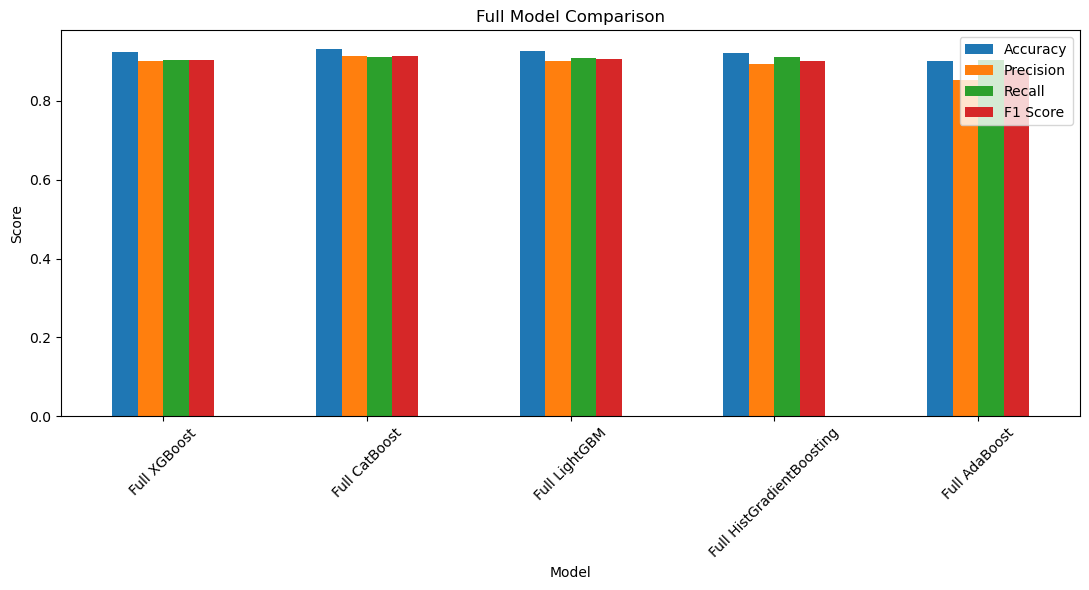

In [36]:
comparison_full.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(11, 6)
)
plt.title("Full Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
full_models_preds = {
    "Full XGBoost": y_pred_xgb_f,
    "Full CatBoost": y_pred_cat_f,
    "Full LightGBM": y_pred_lgb_f,
    "Full HistGradientBoosting": y_pred_hgb_f,
    "Full AdaBoost": y_pred_ada_f
}

for model_name, preds in full_models_preds.items():
    print(f"\n{'='*50}")
    print(model_name)
    print(classification_report(y_test_f, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_f, preds))


Full XGBoost
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       442
           1       0.90      0.90      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726

Confusion Matrix:
[[414  28]
 [ 27 257]]

Full CatBoost
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       442
           1       0.92      0.91      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0.93      0.93      0.93       726

Confusion Matrix:
[[418  24]
 [ 25 259]]

Full LightGBM
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       442
           1       0.90      0.91      0.91       284

    accuracy                           0.93       726
  

In [38]:
comparison_final = pd.DataFrame([
    evaluate_model("Early XGBoost", y_test_e, y_pred_xgb_e),
    evaluate_model("Early CatBoost", y_test_e, y_pred_cat_e),
    evaluate_model("Early LightGBM", y_test_e, y_pred_lgb_e),
    evaluate_model("Early HistGradientBoosting", y_test_e, y_pred_hgb_e),
    evaluate_model("Early AdaBoost", y_test_e, y_pred_ada_e),

    evaluate_model("Full XGBoost", y_test_f, y_pred_xgb_f),
    evaluate_model("Full CatBoost", y_test_f, y_pred_cat_f),
    evaluate_model("Full LightGBM", y_test_f, y_pred_lgb_f),
    evaluate_model("Full HistGradientBoosting", y_test_f, y_pred_hgb_f),
    evaluate_model("Full AdaBoost", y_test_f, y_pred_ada_f),
])

comparison_final

,Model,Accuracy,Precision,Recall,F1 Score
0,Early XGBoost,0.907713,0.878049,0.887324,0.882662
1,Early CatBoost,0.903581,0.876761,0.876761,0.876761
2,Early LightGBM,0.911846,0.884615,0.890845,0.887719
3,Early HistGradientBoosting,0.902204,0.868512,0.883803,0.876091
4,Early AdaBoost,0.867769,0.815436,0.855634,0.835052
5,Full XGBoost,0.924242,0.901754,0.904930,0.903339
6,Full CatBoost,0.932507,0.915194,0.911972,0.913580
7,Full LightGBM,0.925620,0.902098,0.908451,0.905263
8,Full HistGradientBoosting,0.922865,0.893103,0.911972,0.902439
9,Full AdaBoost,0.902204,0.853821,0.904930,0.878632


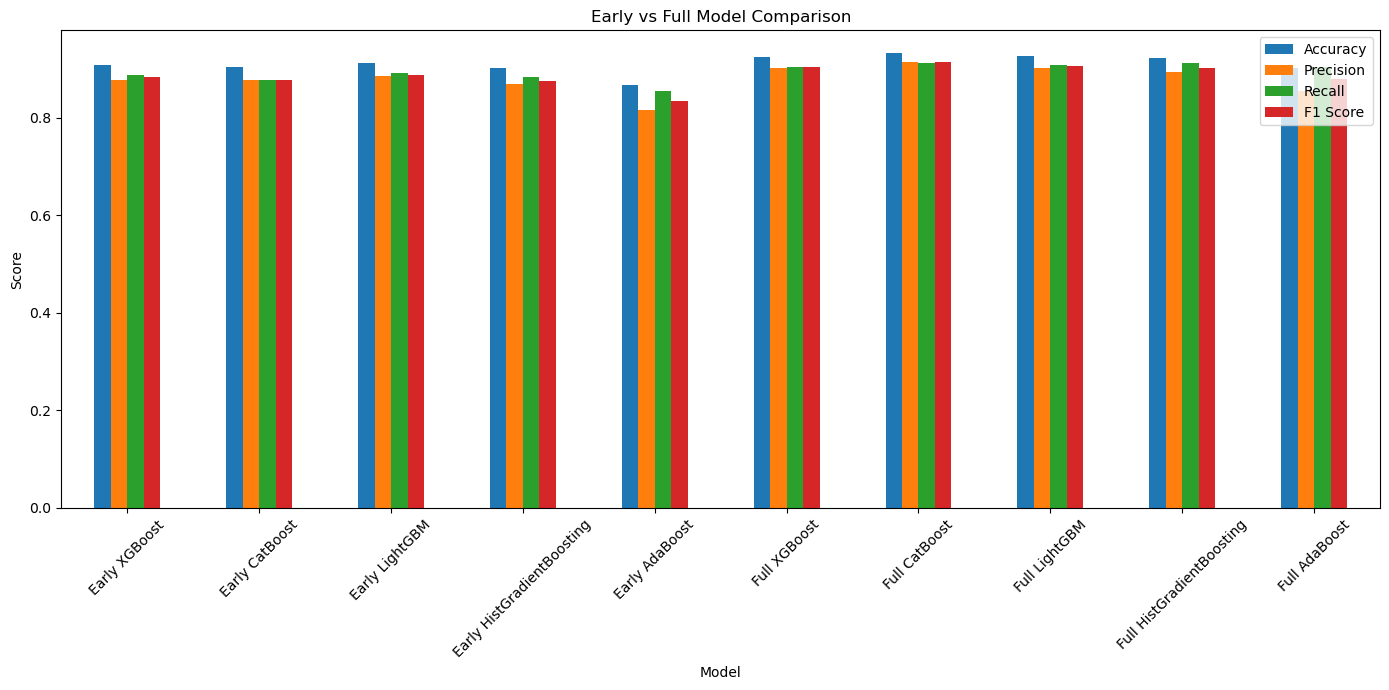

In [39]:
comparison_final.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(14, 7)
)
plt.title("Early vs Full Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 Features - Early Model (LightGBM)
                               Feature  Importance
12                     Admission_grade         486
24  Curricular_units_1st_sem_approved_         483
25     Curricular_units_1st_sem_grade_         402
6        Previous_qualification_grade_         393
3                               Course         370
27                   Unemployment_rate         294
29                                 GDP         255
22  Curricular_units_1st_sem_enrolled_         246
19                   Age_at_enrollment         221
10                 Mother_s_occupation         196


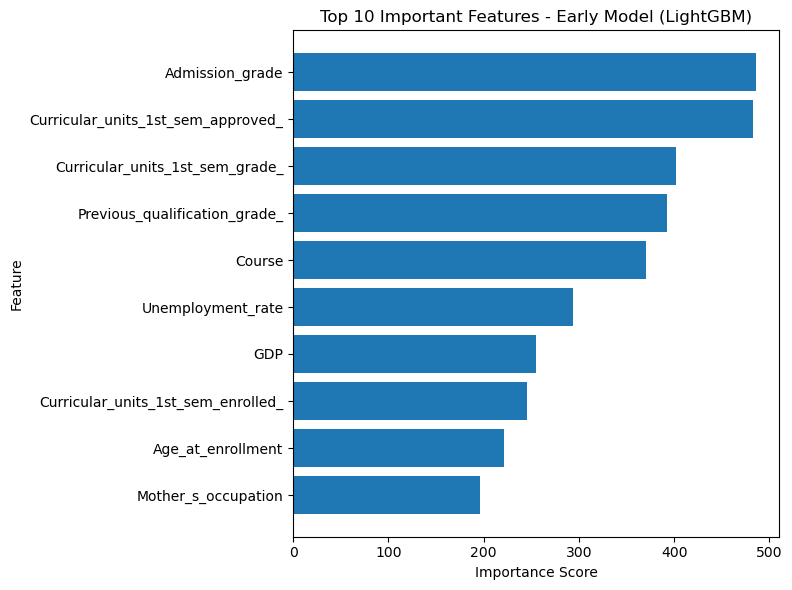

In [40]:
# Early Model Feature Importance (LightGBM)

importance_early = pd.DataFrame({
    "Feature": X_early.columns,
    "Importance": lgb_model_e.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

print("Top 10 Features - Early Model (LightGBM)")
print(importance_early)

plt.figure(figsize=(8,6))
plt.barh(importance_early["Feature"][::-1], importance_early["Importance"][::-1])
plt.title("Top 10 Important Features - Early Model (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Top 10 Features - Full Model (CatBoost)
                               Feature  Importance
30  Curricular_units_2nd_sem_approved_   29.664895
16             Tuition_fees_up_to_date   10.402490
24  Curricular_units_1st_sem_approved_    6.524463
3                               Course    5.530316
31     Curricular_units_2nd_sem_grade_    4.894654
28  Curricular_units_2nd_sem_enrolled_    4.500824
12                     Admission_grade    3.273767
18                  Scholarship_holder    3.107622
22  Curricular_units_1st_sem_enrolled_    2.930929
6        Previous_qualification_grade_    2.825206


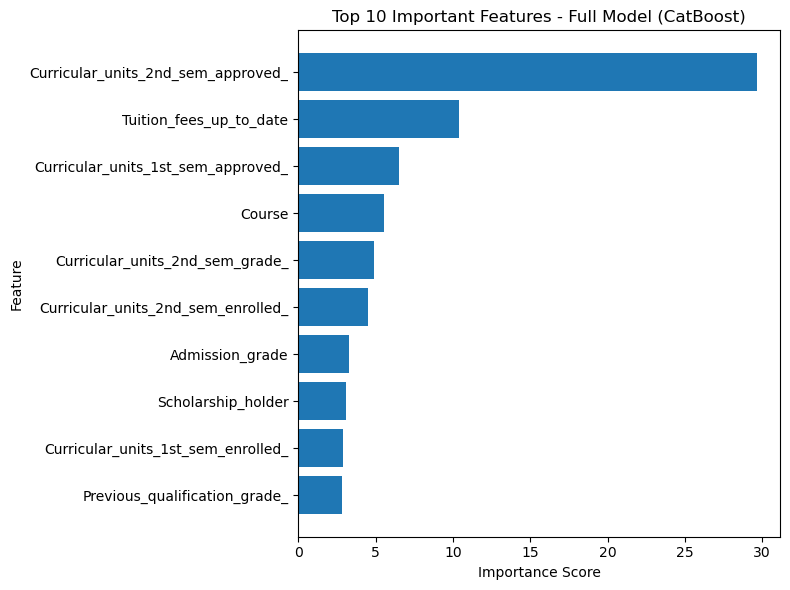

In [41]:
# Full Model Feature Importance (CatBoost)

importance_full = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance": cat_model_f.get_feature_importance()
}).sort_values(by="Importance", ascending=False).head(10)

print("Top 10 Features - Full Model (CatBoost)")
print(importance_full)

plt.figure(figsize=(8,6))
plt.barh(importance_full["Feature"][::-1], importance_full["Importance"][::-1])
plt.title("Top 10 Important Features - Full Model (CatBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()